Enabling R in Colab

In [ ]:
%load_ext rpy2.ipython


Installing R support

In [ ]:
!pip install rpy2

In [ ]:
import pandas as pd

Loading Dataset

In [ ]:
import pandas as pd

deliveries = pd.read_csv(
    '/content/cleaned_deliveries.csv'
)

drivers = pd.read_csv(
    '/content/cleaned_drivers.csv'
)

vehicles = pd.read_csv(
    '/content/cleaned_vehicles.csv'
)

incidents = pd.read_csv(
    '/content/cleaned_incidents.csv'
)

complaints = pd.read_csv(
    '/content/cleaned_complaints.csv'
)

customers = pd.read_csv(
    '/content/cleaned_customers.csv'
)

orders = pd.read_csv(
    '/content/cleaned_orders.csv'
)

hubs = pd.read_csv(
    '/content/cleaned_hubs.csv'
)

cleaned_app_events = pd.read_csv(
    '/content/cleaned_app_events.csv'
)


In [ ]:
print(deliveries.head())

  delivery_id order_id driver_id vehicle_id hub_id        dispatch_time  \
0     DL00001   O00938      D004       V056    H05  2024-06-18 10:57:00   
1     DL00002   O00004      D138       V007    H02  2025-01-11 18:45:00   
2     DL00003   O00639      D006       V049    H02  2025-06-02 20:39:00   
3     DL00004   O00313      D116       V055    H02  2024-03-08 23:31:00   
4     DL00005   O00844      D108       V034    H01  2025-09-21 11:43:00   

        delivery_completed_at delivery_status  route_distance_km  \
0  2024-06-19 09:05:59.904311          Failed              17.26   
1  2025-01-11 17:39:00.000000          OnTime              10.34   
2  2025-06-02 21:45:32.366770          OnTime               7.92   
3  2024-03-09 23:30:08.103702         Delayed              16.42   
4  2025-09-21 15:45:34.131056          OnTime              14.52   

   manual_route_override_count  proof_of_completion_missing  \
0                            1                            0   
1             

Creating Delivery Duration

In [ ]:
deliveries['dispatch_time'] = pd.to_datetime(
    deliveries['dispatch_time']
)

deliveries['delivery_completed_at'] = pd.to_datetime(
    deliveries['delivery_completed_at']
)

deliveries['delivery_duration'] = (
    deliveries['delivery_completed_at']
    -
    deliveries['dispatch_time']
).dt.total_seconds() / 60

print(
    deliveries[
        [
            'dispatch_time',
            'delivery_completed_at',
            'delivery_duration'
        ]
    ].head()
)

        dispatch_time      delivery_completed_at  delivery_duration
0 2024-06-18 10:57:00 2024-06-19 09:05:59.904311        1328.998405
1 2025-01-11 18:45:00 2025-01-11 17:39:00.000000         -66.000000
2 2025-06-02 20:39:00 2025-06-02 21:45:32.366770          66.539446
3 2024-03-08 23:31:00 2024-03-09 23:30:08.103702        1439.135062
4 2025-09-21 11:43:00 2025-09-21 15:45:34.131056         242.568851


Sending Data to R

In [ ]:
%R -i deliveries

In [ ]:
%%R

head(deliveries)

  delivery_id order_id driver_id vehicle_id hub_id       dispatch_time
0     DL00001   O00938      D004       V056    H05 2024-06-18 10:57:00
1     DL00002   O00004      D138       V007    H02 2025-01-11 18:45:00
2     DL00003   O00639      D006       V049    H02 2025-06-02 20:39:00
3     DL00004   O00313      D116       V055    H02 2024-03-08 23:31:00
4     DL00005   O00844      D108       V034    H01 2025-09-21 11:43:00
5     DL00006   O00029      D037       V098    H03 2024-09-11 12:40:00
  delivery_completed_at delivery_status route_distance_km
0   2024-06-19 09:05:59          Failed             17.26
1   2025-01-11 17:39:00          OnTime             10.34
2   2025-06-02 21:45:32          OnTime              7.92
3   2024-03-09 23:30:08         Delayed             16.42
4   2025-09-21 15:45:34          OnTime             14.52
5   2024-09-12 17:11:52         Delayed             13.84
  manual_route_override_count proof_of_completion_missing
0                           1          

Installing R Packages

In [ ]:
%%R

install.packages('sqldf')
install.packages('ggplot2')
install.packages('dplyr')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’

trying URL 'https://cran.rstudio.com/src/contrib/gsubfn_0.7.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/proto_1.0.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/RSQLite_3.52.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/chron_2.3-62.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/sqldf_0.4-12.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmpM8FuRT/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/ggplot2_4.0.3.tar.gz'
Content type 'application/x-gzip' length 6327703 bytes (6.0 MB)
downloaded 6.0 MB


The downloaded source packages are in
	‘/tmp/RtmpM8FuRT/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cra

In [ ]:
%%R

library(sqldf)

library(ggplot2)

library(dplyr)

Loading required package: gsubfn
Loading required package: proto
Loading required package: RSQLite

Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

In addition: Warning message:
no DISPLAY variable so Tk is not available 


SQL Queries in R


In [ ]:
%%R

status_query <- sqldf("

SELECT
    delivery_status,
    COUNT(*) AS total

FROM deliveries

GROUP BY delivery_status

")

print(status_query)

  delivery_status total
1         Delayed   202
2          Failed   132
3          OnTime   616


Driver Performance Analysis

In [ ]:
%%R

driver_query <- sqldf("

SELECT
    driver_id,
    AVG(delivery_duration) AS avg_duration

FROM deliveries

GROUP BY driver_id

ORDER BY avg_duration DESC

")

print(driver_query)

    driver_id avg_duration
1        D063   1303.75093
2        D062   1261.36215
3        D040   1124.62213
4        D023   1117.94847
5        D055   1109.52253
6        D057   1068.54163
7        D170   1035.45577
8        D001   1033.71471
9        D092   1018.19093
10       D152    996.62052
11       D076    994.55664
12       D104    949.15427
13       D095    948.16722
14       D165    946.24784
15       D041    918.13972
16       D109    880.40707
17       D026    880.20294
18       D103    877.12180
19       D085    871.70926
20       D117    871.49366
21       D016    865.72563
22       D082    864.56602
23       D011    864.31089
24       D167    863.82569
25       D022    860.07075
26       D144    849.24664
27       D024    840.86871
28       D114    824.55331
29       D010    803.61098
30       D141    799.61455
31       D154    772.13198
32       D148    767.48178
33       D046    763.84965
34       D111    748.16324
35       D050    746.27347
36       D081    743.39795
3

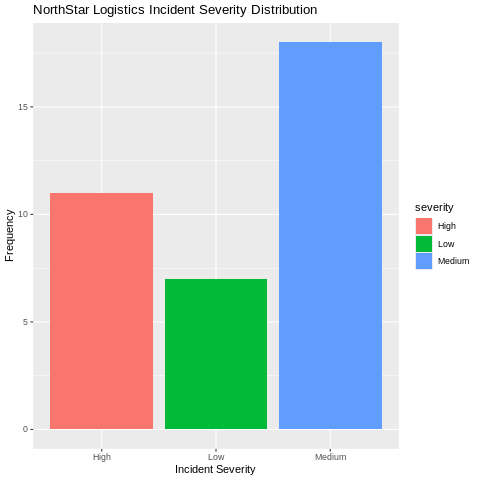

In [ ]:
%%R

library(ggplot2)

incident_data <- data.frame(
  severity = c("Low", "Medium", "High"),
  count = c(7, 18, 11)
)

ggplot(incident_data,
       aes(x = severity,
           y = count,
           fill = severity)) +
geom_bar(stat = "identity") +
labs(
    title = "NorthStar Logistics Incident Severity Distribution",
    x = "Incident Severity",
    y = "Frequency"
)

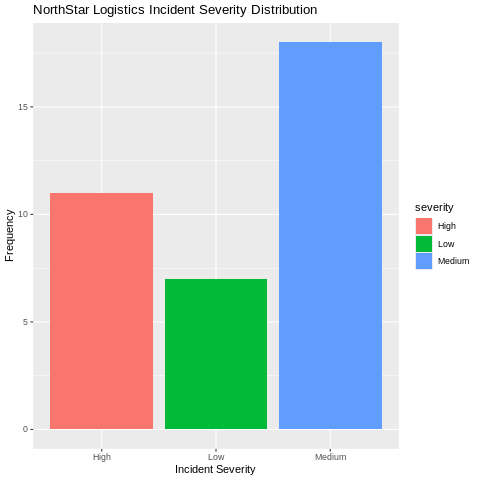

In [ ]:
%%R

library(ggplot2)

incident_data <- data.frame(
  severity = c("Low", "Medium", "High"),
  count = c(7, 18, 11)
)

ggplot(incident_data,
       aes(x = severity,
           y = count,
           fill = severity)) +
geom_bar(stat = "identity") +
labs(
    title = "NorthStar Logistics Incident Severity Distribution",
    x = "Incident Severity",
    y = "Frequency"
)

Route Override Analysis

In [ ]:
%%R

override_query <- sqldf("

SELECT
    manual_route_override_count,
    AVG(delivery_duration) AS avg_duration

FROM deliveries

GROUP BY manual_route_override_count

ORDER BY manual_route_override_count

")

print(override_query)

  manual_route_override_count avg_duration
1                           0     583.4617
2                           1     574.4910
3                           2     552.6164
4                           3     521.0019
5                           4     588.3707
6                           5     594.0697
7                           7    1293.1358


Customer Satisfaction Analysis

In [ ]:
%%R

rating_query <- sqldf("

SELECT
    delivery_status,
    AVG(customer_rating_post_delivery)
    AS avg_rating

FROM deliveries

GROUP BY delivery_status

")

print(rating_query)

  delivery_status avg_rating
1         Delayed   3.133532
2          Failed   3.055490
3          OnTime   4.277837


In [ ]:
%R -i complaints

In [ ]:
%%R

head(complaints)

  complaint_id customer_id order_id complaint_type channel severity
0       CP0001       C0464   O00814       AppIssue     App     High
1       CP0002       C0056   O00628   MissedPickup   Phone   Medium
2       CP0003       C0469   O00384          Delay Chatbot     High
3       CP0004       C0631   O00406          Delay     App   Medium
4       CP0005       C0535   O00154          Delay   Email   Medium
5       CP0006       C0096   O00147          Delay     App   Medium
           created_at           status resolution_days compensation_amount
0 2025-03-30 02:36:00             Open              11               23.99
1 2024-11-07 10:05:00             Open               4               21.64
2 2024-01-02 15:47:00             Open              16               26.41
3 2025-01-14 13:07:00 AwaitingCustomer               7               23.44
4 2024-08-31 05:56:00         Resolved               1               16.18
5 2024-07-22 07:43:00         Resolved               9               18.51

Complaint Analysis

In [ ]:
%%R

complaint_query <- sqldf("

SELECT
    complaint_type,
    COUNT(*) AS total

FROM complaints

GROUP BY complaint_type

ORDER BY total DESC

")

print(complaint_query)

     complaint_type total
1             Delay   101
2      MissedPickup    64
3          AppIssue    53
4   DriverBehaviour    51
5 SupportExperience    20
6           Billing    16
7            Damage    15


R Visualisations

Delivery Duration Histogram

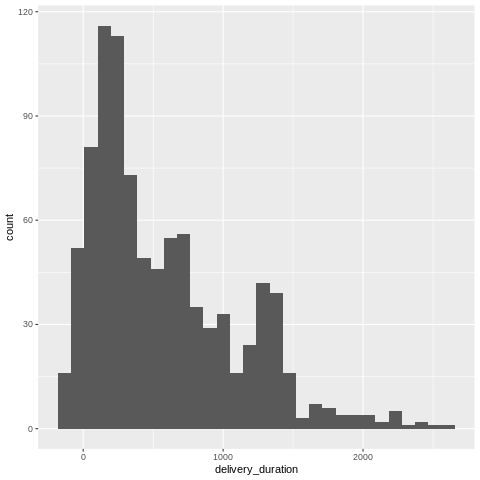

In [ ]:
%%R

ggplot(
    deliveries,
    aes(x=delivery_duration)
) +

geom_histogram(
    bins=30
)

Driver Performance Boxplot


(`stat_boxplot()`). 



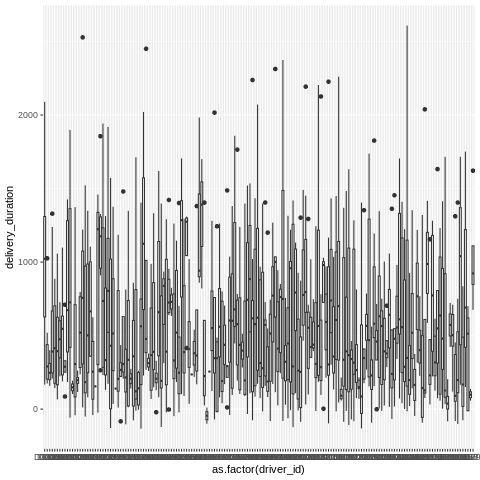

In [ ]:
%%R

ggplot(
    deliveries,
    aes(
        x=as.factor(driver_id),
        y=delivery_duration
    )
) +

geom_boxplot()

Route Override Scatterplot


(`geom_point()`). 



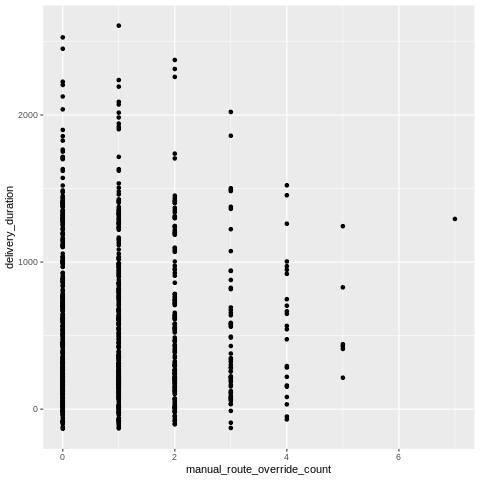

In [ ]:
%%R

ggplot(
    deliveries,
    aes(
        x=manual_route_override_count,
        y=delivery_duration
    )
) +

geom_point()

Delivery Status Bar Chart

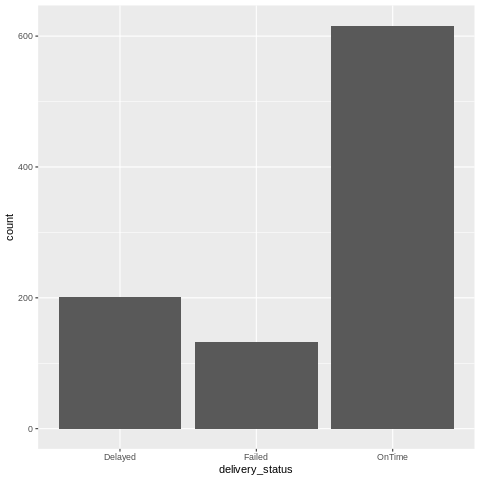

In [ ]:
%%R

ggplot(
    deliveries,
    aes(x=delivery_status)
) +

geom_bar()

Correlation Analysis

In [ ]:
%%R

cor(

deliveries$manual_route_override_count,

deliveries$delivery_duration

)

[1] NA


In [ ]:
%%R

cor(

deliveries$manual_route_override_count,

deliveries$delivery_duration,

use = "complete.obs"

)

[1] -0.01371063


Analytics

In [ ]:
%%R

summary(deliveries)

    delivery_id       order_id       driver_id       vehicle_id 
 Length   :950   Length   :950   Length   :950   Length   :950  
 N.unique :950   N.unique :950   N.unique :170   N.unique :120  
 N.blank  :  0   N.blank  :  0   N.blank  :  0   N.blank  :  0  
 Min.nchar:  7   Min.nchar:  6   Min.nchar:  4   Min.nchar:  4  
 Max.nchar:  7   Max.nchar:  6   Max.nchar:  4   Max.nchar:  4  
                                                                
                                                                
       hub_id    dispatch_time                 delivery_completed_at        
 Length   :950   Min.   :2024-01-01 03:20:00   Min.   :2024-01-01 15:35:48  
 N.unique :  8   1st Qu.:2024-06-21 17:54:00   1st Qu.:2024-06-18 14:13:03  
 N.blank  :  0   Median :2024-12-12 14:19:30   Median :2024-12-13 02:04:50  
 Min.nchar:  3   Mean   :2024-12-20 13:10:27   Mean   :2024-12-19 20:19:52  
 Max.nchar:  3   3rd Qu.:2025-06-12 01:39:15   3rd Qu.:2025-06-12 00:14:26  
                 M

Multi-Variable Correlation Analysis

In [ ]:
%%R

numeric_data <- deliveries[, c(
    "route_distance_km",
    "manual_route_override_count",
    "fuel_or_charge_cost",
    "customer_rating_post_delivery",
    "delivery_duration"
)]

cor(
    numeric_data,
    use = "complete.obs"
)

                              route_distance_km manual_route_override_count
route_distance_km                    1.00000000                  0.20687830
manual_route_override_count          0.20687830                  1.00000000
fuel_or_charge_cost                  0.52035460                  0.09502078
customer_rating_post_delivery        0.02787383                 -0.05749244
delivery_duration                    0.02050526                 -0.01371063
                              fuel_or_charge_cost customer_rating_post_delivery
route_distance_km                      0.52035460                    0.02787383
manual_route_override_count            0.09502078                   -0.05749244
fuel_or_charge_cost                    1.00000000                   -0.06568266
customer_rating_post_delivery         -0.06568266                    1.00000000
delivery_duration                      0.04937784                   -0.30460222
                              delivery_duration
route_distance_k

Delay Risk Analysis

In [ ]:
%%R

delay_analysis <- sqldf("

SELECT

CASE

WHEN delivery_duration < 30
THEN 'Fast'

WHEN delivery_duration BETWEEN 30 AND 60
THEN 'Moderate'

ELSE 'High Delay'

END AS delay_category,

COUNT(*) AS total

FROM deliveries

GROUP BY delay_category

")

print(delay_analysis)

  delay_category total
1           Fast    91
2     High Delay   837
3       Moderate    22


Customer Experience Analysis

In [ ]:
%%R

customer_analysis <- sqldf("

SELECT

delivery_status,

AVG(customer_rating_post_delivery)
AS avg_rating,

AVG(delivery_duration)
AS avg_duration

FROM deliveries

GROUP BY delivery_status

")

print(customer_analysis)

  delivery_status avg_rating avg_duration
1         Delayed   3.133532     810.5981
2          Failed   3.055490    1066.9491
3          OnTime   4.277837     389.1987
